## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

# Topic 1 : Bank Customer Churn Prediction

## Problem Statement

A retail bank makes most of its money from the deposits sitting in its customers'
savings accounts. When a customer goes quiet and lets their balance drop, the bank
loses that funding, and by the time anyone notices, the customer is usually gone.
Winning a new customer costs far more than keeping an existing one, so the bank
wants to know **who is about to leave, while there is still time to act**.

**Data Science Problem Statement:**
Using data for 28k customers,
can we predict which customers will churn (let their balance fall below the required
minimum) so the retention team can target them before they leave?

**Goal:**
Build a classification model that flags likely churners. Because only small amount of
customers churn, plain accuracy would be misleading, so success will be measured on
**recall** (catching as many real churners as possible) and **ROC-AUC**.

**Approach:**
1. Clean the data (fix hidden nulls, handle the extreme skew).
2. Explore how balances, credits and debits differ between churners and non-churners.
3. Engineer features such as balance change between months.
4. Train and compare classification models, handling the class imbalance.
5. Evaluate with recall, precision, F1 and ROC-AUC.

## Data Info
Data Source : Kaggle: https://www.kaggle.com/datasets/pentakrishnakishore/bank-customer-churn-data?select=churn_prediction.csv

File used: churn_prediction.csv

Rows: 28.4k

Columns: 21

Target: churn

## Data Dictionary

| Column | Type | Description |
| --- | --- | --- |
| customer_id | int | Unique identifier for each customer (not a feature) |
| vintage | int | Number of days the customer has been with the bank |
| age | int | Age of the customer |
| gender | object | Gender of the customer (Male / Female) |
| dependents | float | Number of dependents the customer has |
| occupation | object | Occupation (self_employed, salaried, retired, student, company) |
| city | float | Code of the city where the customer is located |
| customer_nw_category | int | Net-worth category of the customer (1 = high, 3 = low) |
| branch_code | int | Code of the branch the customer belongs to |
| current_balance | float | Current balance in the customer's account |
| previous_month_end_balance | float | Account balance at the end of the previous month |
| average_monthly_balance_prevQ | float | Average monthly balance in the previous quarter |
| average_monthly_balance_prevQ2 | float | Average monthly balance in the quarter before that |
| current_month_credit | float | Total money credited (paid in) this month |
| previous_month_credit | float | Total money credited (paid in) last month |
| current_month_debit | float | Total money debited (taken out) this month |
| previous_month_debit | float | Total money debited (taken out) last month |
| current_month_balance | float | Average account balance in the current month |
| previous_month_balance | float | Average account balance in the previous month |
| **churn** | int | **TARGET** — 1 = customer churned, 0 = customer stayed |
| last_transaction | object | Date of the customer's last transaction |

In [66]:
# start you EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [67]:
churn_df = pd.read_csv('./data/churn_prediction.csv')
churn_df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [68]:
churn_df.shape

(28382, 21)

In [69]:
churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  str    
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  str    
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  28382 non-n

In [70]:
churn_df.isnull().sum()

customer_id                          0
vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
last_transaction                     0
dtype: int64

In [71]:
churn_df.duplicated().sum()

np.int64(0)

In [125]:
# What is your target column and what does it represent?
churn_df['churn'].value_counts(normalize=True)
# Target in ['churn'] 0 did not churn, 1 did churn (the customer left the bank 'let their account balance fall below the requierd balance')

churn
0    0.814671
1    0.185329
Name: proportion, dtype: float64

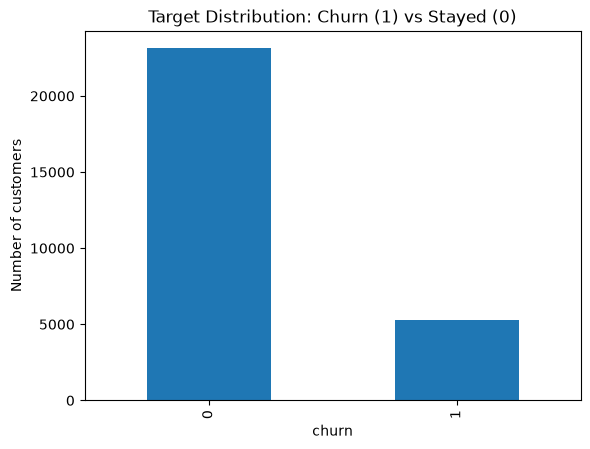

In [73]:
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
churn_df['churn'].value_counts().plot(kind='bar',
                                      title='Target Distribution: Churn (1) vs Stayed (0)')
plt.xlabel('churn')
plt.ylabel('Number of customers')
plt.show()

In [74]:
# The target is categorical, and not balanced.

In [75]:
# What types of features do you have (categorical / numerical)? how many of each ?
churn_df.dtypes.value_counts()

float64    12
int64       6
str         3
Name: count, dtype: int64

| Category | Count | Columns |
| --- | --- | --- |
| Identifier (drop) | 1 | `customer_id` (28,382 unique = one per row) |
| Numerical / continuous | 13 | `vintage`, `age`, `dependents`, and the 10 balance / credit / debit columns |
| Categorical | 5 | `gender`, `occupation`, `customer_nw_category` (3 values), `city` (1,604 codes), `branch_code` (3,185 codes) |
| Date | 1 | `last_transaction` |
| Target | 1 | `churn` |

So: **13 numerical features and 5 categorical features.**

In [76]:
# How many null values does each feature have? what's your plan for each?
churn_df.isnull().sum().sort_values(ascending=False)

dependents                        2463
city                               803
gender                             525
occupation                          80
customer_id                          0
vintage                              0
age                                  0
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
last_transaction                     0
dtype: int64

In [77]:
# some nulls are hidden as text and pandas does not count them.
# The last_transaction column stores missing dates as the st 'NaT'.
(churn_df['last_transaction'] == 'NaT').sum()

np.int64(3223)

In [78]:
churn_df['dependents'].describe()

count    25919.000000
mean         0.347236
std          0.997661
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         52.000000
Name: dependents, dtype: float64

In [79]:
churn_df['dependents'].mode()

0    0.0
Name: dependents, dtype: float64

In [80]:
# so, 'last_transaction': 3223 nulls, I will convert the column with to_datetime() so they become real nulls, then use them ( a customer with no last transaction date is probably already dormant, which is useful information. )
# `dependents': 2463, I will fill with the mode(0), since the median and the 75th percentile are both 0, most customers have no dependents.
# `city`: 803, I will fill with a constant as 'unknown' and treat it as its own category.
# `gender`: 525, I will fill with 'unknown' as a third category.
# `occupation`: 80, I will fill with the mode, too small to affect anything anyway.

In [81]:
# Which features are most correlated with your target, and with each other?
# Drop the ID and the two location-code columns first, because a correlation on a branch code or a city code is meaningless.
corr_df = churn_df.drop(columns=['customer_id', 'branch_code', 'city'])

corr_with_churn = corr_df.corr(numeric_only=True)['churn']
corr_with_churn.abs().sort_values(ascending=False)

churn                             1.000000
previous_month_debit              0.073058
current_month_debit               0.048041
previous_month_credit             0.042179
dependents                        0.033487
current_balance                   0.024181
current_month_credit              0.020755
age                               0.020012
average_monthly_balance_prevQ2    0.018376
previous_month_balance            0.014593
average_monthly_balance_prevQ     0.011960
previous_month_end_balance        0.006886
customer_nw_category              0.006551
current_month_balance             0.006391
vintage                           0.004769
Name: churn, dtype: float64

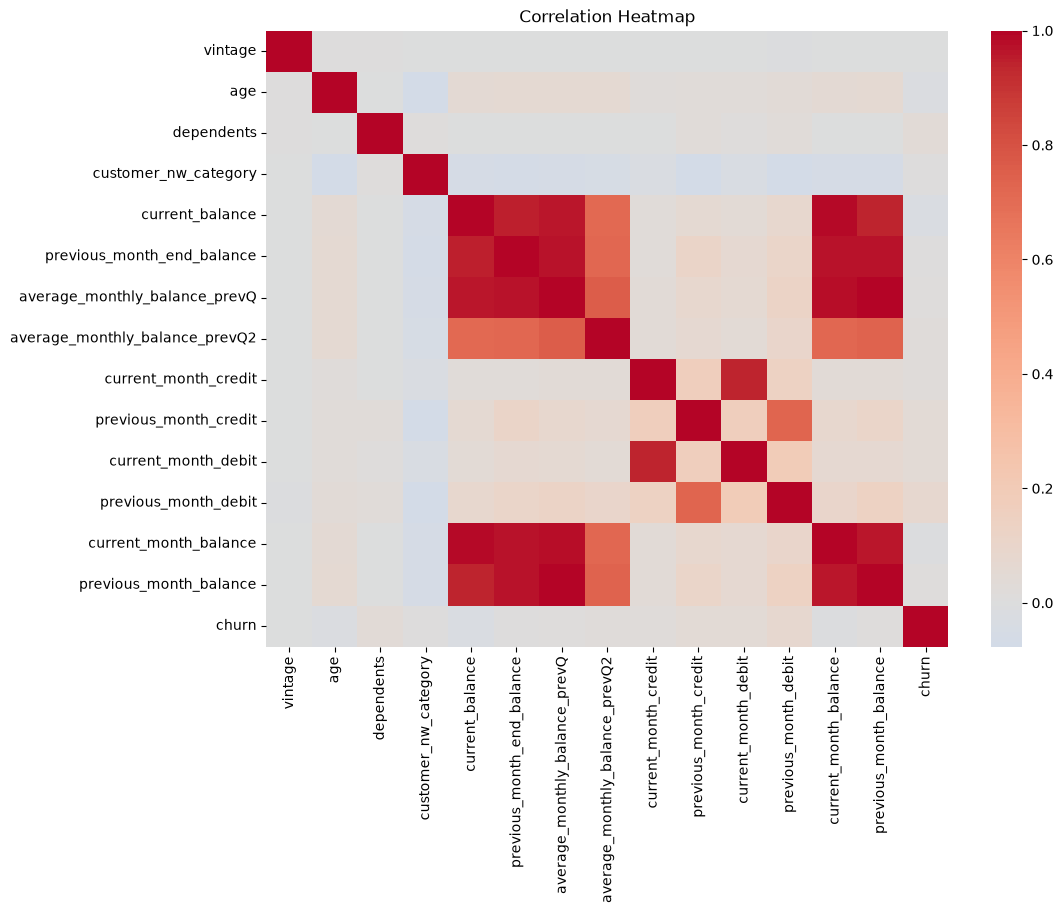

In [82]:
plt.figure(figsize=(11, 8))
sns.heatmap(corr_df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [83]:
# Are there outliers? how would you handle them?

money_cols = ['current_balance', 'previous_month_end_balance',
              'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2',
              'current_month_credit', 'previous_month_credit',
              'current_month_debit', 'previous_month_debit',
              'current_month_balance', 'previous_month_balance']

# an outlier is any value below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
for col in money_cols:
    Q1 = churn_df[col].quantile(0.25)
    Q3 = churn_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = churn_df[(churn_df[col] < Q1 - 1.5 * IQR) | (churn_df[col] > Q3 + 1.5 * IQR)]
    print(f'{col} {len(outliers)} outliers')

current_balance 2739 outliers
previous_month_end_balance 2731 outliers
average_monthly_balance_prevQ 2727 outliers
average_monthly_balance_prevQ2 2612 outliers
current_month_credit 4558 outliers
previous_month_credit 4682 outliers
current_month_debit 3935 outliers
previous_month_debit 4075 outliers
current_month_balance 2697 outliers
previous_month_balance 2720 outliers


In [84]:
churn_df[money_cols].skew().sort_values(ascending=False).round(1)

current_month_credit              143.3
current_month_debit               115.6
current_balance                    99.0
current_month_balance              97.3
average_monthly_balance_prevQ      96.6
previous_month_balance             93.4
previous_month_end_balance         92.9
average_monthly_balance_prevQ2     88.9
previous_month_credit              42.6
previous_month_debit               30.6
dtype: float64

In [85]:
# So, yes and a lot.
# to handle them, I will check thre outlier meaning first, a customer huge acc balance is exactly who the bank cannot afford to lose, so I will not drop it.
#  I can use log transform.
# And so on with the rest.

# Topic 2 : SBA Small Business Loan Default Prediction

## Problem Statement

The U.S. Small Business Administration (SBA) helps small businesses get bank loans by
**guaranteeing part of the loan**. If the business defaults, the SBA meaning the
taxpayer pays back the guaranteed share. The bank still loses the rest, so the bank
has to decide whether the loan is worth the risk in the first place.

**Data Science Problem Statement:**
Using ~900k historical SBA-guaranteed loans, can we
predict whether a new loan will be **paid in full** or **charged off** (defaulted),
based on the loan terms, the business, and the industry?

**Goal:**
Build a classification model that estimates the probability of default so a loan
officer can approve or deny an application with evidence behind the decision. About
18% of loans defaulted, so the target is imbalanced and we will measure success with
**recall** and **ROC-AUC** rather than accuracy.

**Approach:**
1. Clean the data, the money columns are stored as text.
2. Explore how default rates change by loan term, industry, and SBA-guaranteed share.
3. Engineer features suggested by the published research paper behind this dataset.
4. Train and compare classification models, handling the class imbalance.

## Data Info
Data Source: kaggle (https://www.kaggle.com/datasets/mirbektoktogaraev/should-this-loan-be-approved-or-denied?select=SBAnational.csv)

File used: SBAnational.csv

Rows: 900k

Columns: 27

Target: 'MIS_Status'

## Data Dictionary

| Column | Type | Description |
| --- | --- | --- |
| LoanNr_ChkDgt | int | Identifier — primary key (not a feature) |
| Name | object | Borrower name |
| City | object | Borrower city |
| State | object | Borrower state |
| Zip | int | Borrower zip code |
| Bank | object | Name of the lending bank |
| BankState | object | State of the lending bank |
| NAICS | int | Industry classification code (first 2 digits = economic sector) |
| ApprovalDate | object | Date the SBA commitment was issued |
| ApprovalFY | object | Fiscal year of commitment |
| Term | int | Loan term in months |
| NoEmp | int | Number of business employees |
| NewExist | float | 1 = existing business (over 2 years), 2 = new business |
| CreateJob | int | Number of jobs created |
| RetainedJob | int | Number of jobs retained |
| FranchiseCode | int | Franchise code (00000 or 00001 = no franchise) |
| UrbanRural | int | 1 = urban, 2 = rural, 0 = undefined |
| RevLineCr | object | Revolving line of credit: Y = yes, N = no |
| LowDoc | object | LowDoc program (one-page application for loans under \$150k): Y / N |
| ChgOffDate | object | Date the loan was declared in default |
| DisbursementDate | object | Date the money was paid out |
| DisbursementGross | object → float | Amount disbursed (stored as text with `$` and `,`) |
| BalanceGross | object → float | Gross amount outstanding |
| **MIS_Status** | object | **TARGET** — `CHGOFF` = charged off (defaulted), `P I F` = paid in full |
| ChgOffPrinGr | object → float | Charged-off amount |
| GrAppv | object → float | Gross amount of loan approved by the bank |
| SBA_Appv | object → float | Amount of the loan guaranteed by the SBA |

In [86]:
sba_df = pd.read_csv('./data/SBAnational.csv',low_memory=False)
sba_df.head()

,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,84,4,2.0,0,0,1,0,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,60,2,2.0,0,0,1,0,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,180,7,1.0,0,0,1,0,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,60,2,1.0,0,0,1,0,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,240,14,1.0,7,7,1,0,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


In [87]:
sba_df.shape

(899164, 27)

In [88]:
sba_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  str    
 2   City               899134 non-null  str    
 3   State              899150 non-null  str    
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  str    
 6   BankState          897598 non-null  str    
 7   NAICS              899164 non-null  int64  
 8   ApprovalDate       899164 non-null  str    
 9   ApprovalFY         899164 non-null  str    
 10  Term               899164 non-null  int64  
 11  NoEmp              899164 non-null  int64  
 12  NewExist           899028 non-null  float64
 13  CreateJob          899164 non-null  int64  
 14  RetainedJob        899164 non-null  int64  
 15  FranchiseCode      899164 non-null  int64  
 16  UrbanRural   

In [89]:
sba_df.isnull().sum().sort_values(ascending=False)

ChgOffDate           736465
RevLineCr              4528
LowDoc                 2582
DisbursementDate       2368
MIS_Status             1997
BankState              1566
Bank                   1559
NewExist                136
City                     30
State                    14
Name                     14
Term                      0
ApprovalFY                0
ApprovalDate              0
NAICS                     0
Zip                       0
LoanNr_ChkDgt             0
RetainedJob               0
NoEmp                     0
FranchiseCode             0
UrbanRural                0
CreateJob                 0
DisbursementGross         0
BalanceGross              0
ChgOffPrinGr              0
GrAppv                    0
SBA_Appv                  0
dtype: int64

In [90]:
sba_df.duplicated().sum()

np.int64(0)

In [91]:
# The 5 columns stored as text money values
money_cols = ['DisbursementGross', 'BalanceGross', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv']

# what they look like before cleaning
print(sba_df[money_cols].head(3))

  DisbursementGross BalanceGross ChgOffPrinGr        GrAppv      SBA_Appv
0       $60,000.00        $0.00        $0.00    $60,000.00    $48,000.00 
1       $40,000.00        $0.00        $0.00    $40,000.00    $32,000.00 
2      $287,000.00        $0.00        $0.00   $287,000.00   $215,250.00 


In [92]:
# lets strip the spaces, remove the "$" and the "," then convert to float
for col in money_cols:
    sba_df[col] = (sba_df[col].str.strip().str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float))
sba_df[money_cols].head(3)

,DisbursementGross,BalanceGross,ChgOffPrinGr,GrAppv,SBA_Appv
0,60000.0,0.0,0.0,60000.0,48000.0
1,40000.0,0.0,0.0,40000.0,32000.0
2,287000.0,0.0,0.0,287000.0,215250.0


In [93]:
# What is your target column and what does it represent?
sba_df['MIS_Status'].value_counts(dropna=False)

MIS_Status
P I F     739609
CHGOFF    157558
NaN         1997
Name: count, dtype: int64

In [94]:
#  the target is 'MIS_Status'
#  `CHGOFF` = the loan was charged off, meaning the business defaulted
# `P I F` = the loan was paid in full
# Missing : 1,997 loans 

In [95]:
sba_df = sba_df.dropna(subset=['MIS_Status'])

# lets create a clean 0/1 target column. .str.strip() handles the spaces in 'P I F'.
sba_df['Default'] = (sba_df['MIS_Status'].str.strip() == 'CHGOFF').astype(int)

sba_df['Default'].value_counts()

Default
0    739609
1    157558
Name: count, dtype: int64

In [96]:
# Is your target categorical or continuous? is it balanced (Plot the distribution)?

sba_df['Default'].value_counts(normalize=True)

Default
0    0.824383
1    0.175617
Name: proportion, dtype: float64

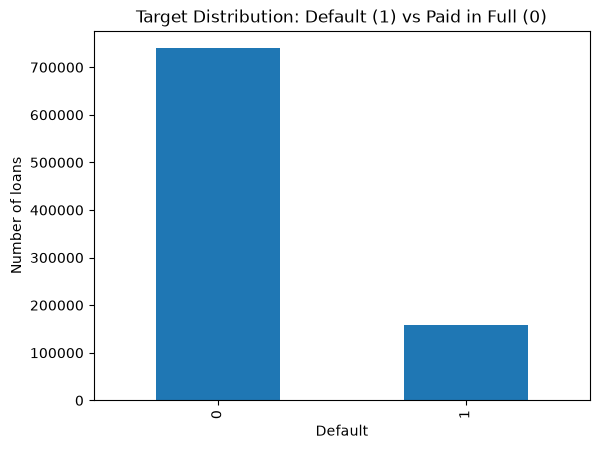

In [97]:
# its categorical, not balanced:

sba_df['Default'].value_counts().plot(kind='bar',title='Target Distribution: Default (1) vs Paid in Full (0)')
plt.xlabel('Default')
plt.ylabel('Number of loans')
plt.show()

In [98]:
# What types of features do you have (categorical / numerical)? how many of each ?
sba_df.dtypes.value_counts()

str        12
int64      10
float64     6
Name: count, dtype: int64

In [99]:
sba_df.nunique().sort_values()

Default                   2
MIS_Status                2
NewExist                  3
UrbanRural                3
LowDoc                    8
BalanceGross             15
RevLineCr                18
ApprovalFY               49
State                    51
BankState                56
CreateJob               246
RetainedJob             357
Term                    412
NoEmp                   598
NAICS                  1312
FranchiseCode          2767
Bank                   5801
ChgOffDate             6444
DisbursementDate       8468
ApprovalDate           9836
GrAppv                22101
City                  32566
Zip                   33602
SBA_Appv              38288
ChgOffPrinGr          83106
DisbursementGross    118086
Name                 778679
LoanNr_ChkDgt        897167
dtype: int64


| Category | Count | Columns |
| --- | --- | --- |
| Identifier (drop) | 1 | `LoanNr_ChkDgt` |
| Free text (drop) | 3 | `Name`, `City`, `Bank` |
| Numerical / continuous | 9 | `Term`, `NoEmp`, `CreateJob`, `RetainedJob`, `DisbursementGross`, `BalanceGross`, `ChgOffPrinGr`, `GrAppv`, `SBA_Appv` |
| Categorical | 8 | `State`, `BankState`, `NAICS`, `NewExist`, `FranchiseCode`, `UrbanRural`, `RevLineCr`, `LowDoc` |
| Date | 3 | `ApprovalDate`, `ChgOffDate`, `DisbursementDate` |
| Other | 2 | `Zip`, `ApprovalFY` |
| Target | 1 | `MIS_Status` |


In [100]:
# How many null values does each feature have? what's your plan for each?

sba_df.isnull().sum().sort_values(ascending=False)

ChgOffDate           734729
RevLineCr              4520
LowDoc                 2578
DisbursementDate       2175
BankState              1513
Bank                   1506
NewExist                134
City                     30
Name                     14
State                    13
Zip                       0
LoanNr_ChkDgt             0
NoEmp                     0
Term                      0
ApprovalFY                0
ApprovalDate              0
NAICS                     0
FranchiseCode             0
CreateJob                 0
RetainedJob               0
UrbanRural                0
DisbursementGross         0
BalanceGross              0
MIS_Status                0
ChgOffPrinGr              0
GrAppv                    0
SBA_Appv                  0
Default                   0
dtype: int64

In [101]:
# # `LowDoc` fill with the mode
# `DisbursementDate` keep as missing
# `BankState` / `Bank` fill with 'unknown'
# `NewExist` fill with the mode
# `City` / `Name` / `State` fill with 'unknown'
# `RevLineCr`, fill with 'unknown'
# `ChgOffDate` Drop the column, this is not really missing data.x

# 747,212 missing values in total, but 734,729 of those sit in a single column:
# `ChgOffDate` is not missing at random. It is because a charge-off date only exists if the loan defaulted. The emptiness is the answer.
# That leads directly to the next point.

In [102]:
# # 
# Some columns record what happened **after** we already know the outcome. If we leave
# them in, the model will look almost perfect and be completely useless in real life,
# because a bank does not have these values when deciding on a new application.

# ChgOffPrinGr is the amount written off. Does it only appear for defaulted loans?
print('Defaulted loans with a charged-off amount > 0 :',((sba_df['Default'] == 1) & (sba_df['ChgOffPrinGr'] > 0)).sum(),'out of', (sba_df['Default'] == 1).sum())
print('Paid-in-full loans with a charged-off amount > 0:',((sba_df['Default'] == 0) & (sba_df['ChgOffPrinGr'] > 0)).sum(),'out of', (sba_df['Default'] == 0).sum())

Defaulted loans with a charged-off amount > 0 : 156871 out of 157558
Paid-in-full loans with a charged-off amount > 0: 4884 out of 739609


In [103]:
# `ChgOffPrinGr` and `ChgOffDate` therefore give away the answer almost perfectly. Both must be dropped before modelling. 

In [104]:
sba_df.columns

Index(['LoanNr_ChkDgt', 'Name', 'City', 'State', 'Zip', 'Bank', 'BankState',
       'NAICS', 'ApprovalDate', 'ApprovalFY', 'Term', 'NoEmp', 'NewExist',
       'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural', 'RevLineCr',
       'LowDoc', 'ChgOffDate', 'DisbursementDate', 'DisbursementGross',
       'BalanceGross', 'MIS_Status', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv',
       'Default'],
      dtype='str')

In [105]:
# Which features are most correlated with your target, and with each other?


# Correlation of each numeric feature with Default (leakage columns excluded)
corr_cols = ['Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'DisbursementGross',
             'GrAppv', 'SBA_Appv', 'NewExist', 'UrbanRural', 'Default']

corr_sba=sba_df[corr_cols].corr(numeric_only=True)['Default']
corr_sba.abs().sort_values(ascending=False)

Default              1.000000
Term                 0.314121
UrbanRural           0.158483
SBA_Appv             0.132232
GrAppv               0.120424
DisbursementGross    0.110799
NoEmp                0.026265
NewExist             0.020288
RetainedJob          0.012352
CreateJob            0.011901
Name: Default, dtype: float64

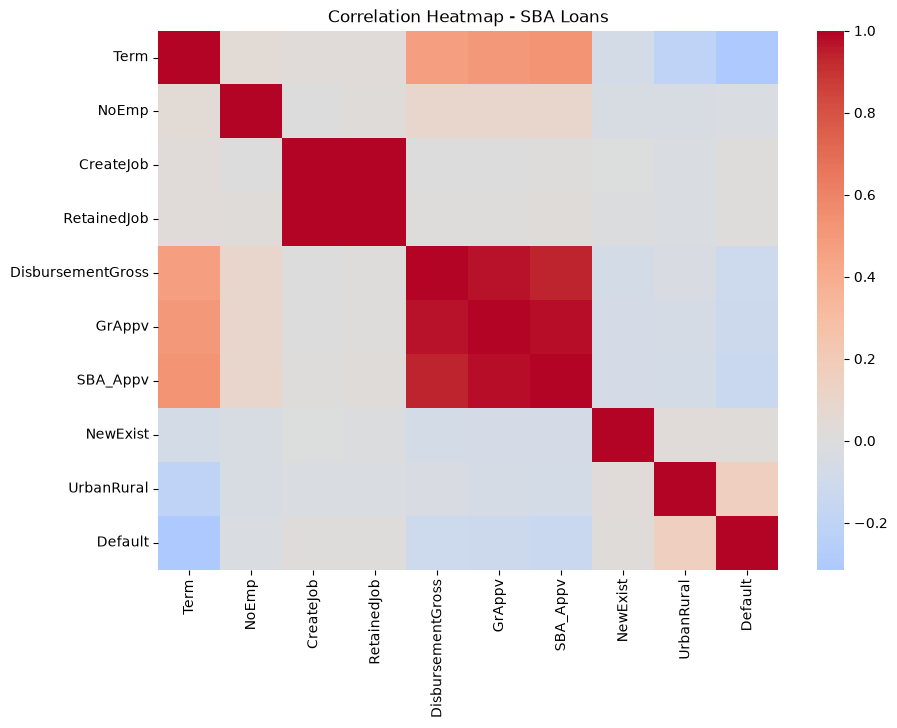

In [106]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(sba_df[corr_cols].corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - SBA Loans')
plt.show()

In [107]:
# Are there outliers? how would you handle them?
# Summary statistics for the main numeric columns
num_cols = ['Term', 'NoEmp', 'CreateJob', 'RetainedJob',
            'DisbursementGross', 'GrAppv', 'SBA_Appv', 'BalanceGross']

sba_df[num_cols].describe()

,Term,NoEmp,CreateJob,RetainedJob,DisbursementGross,GrAppv,SBA_Appv,BalanceGross
count,897167.000000,897167.000000,897167.000000,897167.000000,8.971670e+05,8.971670e+05,8.971670e+05,897167.000000
mean,110.848592,11.412562,8.444305,10.807308,2.015980e+05,1.930595e+05,1.497807e+05,2.996003
std,78.900862,73.793775,236.950249,237.382398,2.878066e+05,2.834331e+05,2.285600e+05,1443.766066
min,0.000000,0.000000,0.000000,0.000000,4.000000e+03,1.000000e+03,5.000000e+02,0.000000
25%,60.000000,2.000000,0.000000,0.000000,4.249200e+04,3.500000e+04,2.125000e+04,0.000000
50%,84.000000,4.000000,0.000000,1.000000,1.000000e+05,9.000000e+04,6.205000e+04,0.000000
75%,120.000000,10.000000,1.000000,4.000000,2.390000e+05,2.250000e+05,1.750000e+05,0.000000
max,569.000000,9999.000000,8800.000000,9500.000000,1.144632e+07,5.472000e+06,5.472000e+06,996262.000000


In [108]:
# Count outliers using the IQR rule
for col in num_cols:
    Q1 = sba_df[col].quantile(0.25)
    Q3 = sba_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = sba_df[(sba_df[col] < Q1 - 1.5 * IQR) | (sba_df[col] > Q3 + 1.5 * IQR)]
    print(f'{col} {len(outliers)} outliers')

Term 158646 outliers
NoEmp 97120 outliers
CreateJob 148795 outliers
RetainedJob 90501 outliers
DisbursementGross 83474 outliers
GrAppv 85509 outliers
SBA_Appv 90158 outliers
BalanceGross 14 outliers


In [109]:
# Outliers should be kept, not deleted
# removing them would cost the data and bias the default rate.

# Topic 3 : Vehicle Loan Default Prediction

## Problem Statement

Financial institutions lose significant money when customers default on vehicle loans.
The usual reaction is to tighten underwriting and reject more applications — but that
also turns away customers who would have paid perfectly well, and the lender loses that
business too.

The hardest case is the customer who defaults on the very first EMI (Equated Monthly
Instalment). Defaulting on payment number one usually means the loan should never have
been approved in the way it was.

**Data Science Problem Statement:**
Using 233k vehicle loans, along with the borrower's
demographics, the loan terms, and their credit bureau history, can we predict which
customers will default on their first EMI?

**Goal:**
Build a classification model that estimates first-EMI default risk, so that customers
capable of repaying are not rejected unnecessarily.
The target is imbalanced and we will measure success with **recall** and **ROC-AUC**
rather than accuracy.

**Approach:**
1. Fix the messy columns, credit history is stored as text and the
   dates of birth need a century correction.
2. Handle the bureau score, where 0 does not mean a score of zero.
3. Explore which factors actually separate defaulters (LTV, loan size, bureau history).
4. Engineer features such as customer age at disbursal and credit history in months.
5. Train and compare classification models, handling the class imbalance.

## Data Info

Data Source : Kaggle (https://www.kaggle.com/datasets/mamtadhaker/lt-vehicle-loan-default-prediction?select=train.csv)

File used: train.csv (later: test.csv)

Rows: 233k

Columns: 41

Target: 'loan_default'

## Data Dictionary

| Column | Type | Description |
| --- | --- | --- |
| UniqueID | int | Identifier for customers (not a feature) |
| disbursed_amount | int | Amount of loan disbursed |
| asset_cost | int | Cost of the vehicle |
| ltv | float | Loan to Value ratio of the asset |
| branch_id | int | Branch where the loan was disbursed |
| supplier_id | int | Vehicle dealer where the loan was disbursed |
| manufacturer_id | int | Vehicle manufacturer (Hero, Honda, TVS etc.) |
| Current_pincode_ID | int | Current pincode of the customer |
| Date.of.Birth | object | Date of birth of the customer |
| Employment.Type | object | Salaried / Self employed |
| DisbursalDate | object | Date of disbursement |
| State_ID | int | State of disbursement |
| Employee_code_ID | int | Employee who logged the disbursement |
| MobileNo_Avl_Flag | int | 1 if mobile number was shared |
| Aadhar_flag | int | 1 if Aadhaar was shared |
| PAN_flag | int | 1 if PAN was shared |
| VoterID_flag | int | 1 if voter ID was shared |
| Driving_flag | int | 1 if driving licence was shared |
| Passport_flag | int | 1 if passport was shared |
| PERFORM_CNS.SCORE | int | Credit bureau score (**0 = no bureau history**) |
| PERFORM_CNS.SCORE.DESCRIPTION | object | Bureau score risk band |
| PRI.NO.OF.ACCTS | int | Total loans taken by the customer (primary = own use) |
| PRI.ACTIVE.ACCTS | int | Count of active primary loans |
| PRI.OVERDUE.ACCTS | int | Count of primary accounts in default |
| PRI.CURRENT.BALANCE | int | Principal outstanding on active primary loans |
| PRI.SANCTIONED.AMOUNT | int | Total sanctioned for all primary loans |
| PRI.DISBURSED.AMOUNT | int | Total disbursed for all primary loans |
| SEC.NO.OF.ACCTS | int | Total secondary loans (customer is co-applicant / guarantor) |
| SEC.ACTIVE.ACCTS | int | Count of active secondary loans |
| SEC.OVERDUE.ACCTS | int | Count of secondary accounts in default |
| SEC.CURRENT.BALANCE | int | Principal outstanding on active secondary loans |
| SEC.SANCTIONED.AMOUNT | int | Total sanctioned for all secondary loans |
| SEC.DISBURSED.AMOUNT | int | Total disbursed for all secondary loans |
| PRIMARY.INSTAL.AMT | int | EMI amount of the primary loan |
| SEC.INSTAL.AMT | int | EMI amount of the secondary loan |
| NEW.ACCTS.IN.LAST.SIX.MONTHS | int | New loans taken in the last 6 months |
| DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS | int | Loans defaulted in the last 6 months |
| AVERAGE.ACCT.AGE | object | Average loan tenure, stored as text `"1yrs 11mon"` |
| CREDIT.HISTORY.LENGTH | object | Time since first loan, stored as text `"1yrs 11mon"` |
| NO.OF_INQUIRIES | int | Loan enquiries made by the customer |
| **loan_default** | int | **TARGET** — 1 = defaulted on the first EMI, 0 = paid |

In [110]:
lt_df = pd.read_csv('./data/train.csv')
lt_df.head()

,UniqueID,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,Current_pincode_ID,Date.of.Birth,Employment.Type,DisbursalDate,State_ID,Employee_code_ID,MobileNo_Avl_Flag,Aadhar_flag,PAN_flag,VoterID_flag,Driving_flag,Passport_flag,PERFORM_CNS.SCORE,PERFORM_CNS.SCORE.DESCRIPTION,PRI.NO.OF.ACCTS,PRI.ACTIVE.ACCTS,PRI.OVERDUE.ACCTS,PRI.CURRENT.BALANCE,PRI.SANCTIONED.AMOUNT,PRI.DISBURSED.AMOUNT,SEC.NO.OF.ACCTS,SEC.ACTIVE.ACCTS,SEC.OVERDUE.ACCTS,SEC.CURRENT.BALANCE,SEC.SANCTIONED.AMOUNT,SEC.DISBURSED.AMOUNT,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NEW.ACCTS.IN.LAST.SIX.MONTHS,DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS,AVERAGE.ACCT.AGE,CREDIT.HISTORY.LENGTH,NO.OF_INQUIRIES,loan_default
0,420825,50578,58400,89.55,67,22807,45,1441,01-01-84,Salaried,03-08-18,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,22807,45,1502,31-07-85,Self employed,26-09-18,6,1998,1,1,0,0,0,0,598,I-Medium Risk,1,1,1,27600,50200,50200,0,0,0,0,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,22807,45,1497,24-08-85,Self employed,01-08-18,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
3,624493,57513,66113,88.48,67,22807,45,1501,30-12-93,Self employed,26-10-18,6,1998,1,1,0,0,0,0,305,L-Very High Risk,3,0,0,0,0,0,0,0,0,0,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
4,539055,52378,60300,88.39,67,22807,45,1495,09-12-77,Self employed,26-09-18,6,1998,1,1,0,0,0,0,0,No Bureau History Available,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1


In [111]:
lt_df.shape

(233154, 41)

In [112]:
lt_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UniqueID                             233154 non-null  int64  
 1   disbursed_amount                     233154 non-null  int64  
 2   asset_cost                           233154 non-null  int64  
 3   ltv                                  233154 non-null  float64
 4   branch_id                            233154 non-null  int64  
 5   supplier_id                          233154 non-null  int64  
 6   manufacturer_id                      233154 non-null  int64  
 7   Current_pincode_ID                   233154 non-null  int64  
 8   Date.of.Birth                        233154 non-null  str    
 9   Employment.Type                      225493 non-null  str    
 10  DisbursalDate                        233154 non-null  str    
 11  State_ID                

In [113]:
lt_df.duplicated().sum()

np.int64(0)

In [114]:
lt_df.isnull().sum()

UniqueID                                  0
disbursed_amount                          0
asset_cost                                0
ltv                                       0
branch_id                                 0
supplier_id                               0
manufacturer_id                           0
Current_pincode_ID                        0
Date.of.Birth                             0
Employment.Type                        7661
DisbursalDate                             0
State_ID                                  0
Employee_code_ID                          0
MobileNo_Avl_Flag                         0
Aadhar_flag                               0
PAN_flag                                  0
VoterID_flag                              0
Driving_flag                              0
Passport_flag                             0
PERFORM_CNS.SCORE                         0
PERFORM_CNS.SCORE.DESCRIPTION             0
PRI.NO.OF.ACCTS                           0
PRI.ACTIVE.ACCTS                

In [124]:
# What is your target column and what does it represent?

lt_df['loan_default'].value_counts(normalize=True)
# Target is 'loan_default', did the customer miss their very first EMI payment?
# 1 = defaulted on the first instalment, 0 = paid it on time

loan_default
0    0.782929
1    0.217071
Name: proportion, dtype: float64

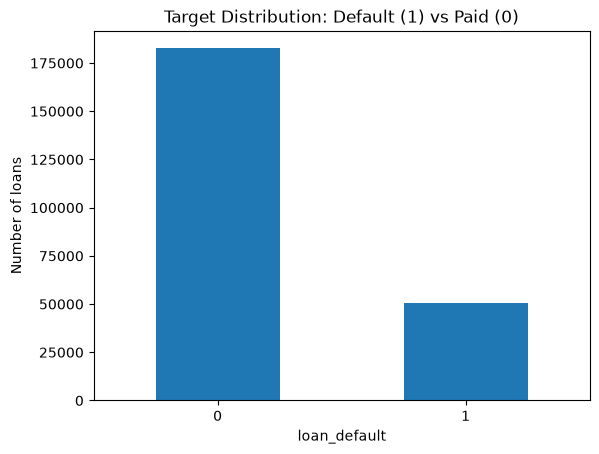

In [116]:
# Is your target categorical or continuous? is it balanced (Plot the distribution)?


lt_df['loan_default'].value_counts().plot(kind='bar',title='Target Distribution: Default (1) vs Paid (0)',rot=0)
plt.xlabel('loan_default')
plt.ylabel('Number of loans')
plt.show()

# The target is categorical, so this is a Classification and is not balanced

In [117]:
# What types of features do you have (categorical / numerical)? how many of each ?
lt_df.dtypes.value_counts()


int64      34
str         6
float64     1
Name: count, dtype: int64

| Category | Count | Columns |
| --- | --- | --- |
| Identifier (drop) | 1 | `UniqueID` |
| Constant (drop) | 1 | `MobileNo_Avl_Flag` — always 1 |
| Numerical | 24 | `disbursed_amount`, `asset_cost`, `ltv`, `PERFORM_CNS.SCORE`, all the `PRI.*` / `SEC.*` account and amount columns, `NEW.ACCTS...`, `DELINQUENT.ACCTS...`, `NO.OF_INQUIRIES` |
| Categorical | 12 | `branch_id`, `supplier_id`, `manufacturer_id`, `Current_pincode_ID`, `State_ID`, `Employee_code_ID`, `Employment.Type`, `PERFORM_CNS.SCORE.DESCRIPTION`, and the 5 ID-proof flags (`Aadhar_flag`, `PAN_flag`, `VoterID_flag`, `Driving_flag`, `Passport_flag`) |
| Date | 2 | `Date.of.Birth`, `DisbursalDate` |
| Text needing parsing | 2 | `AVERAGE.ACCT.AGE`, `CREDIT.HISTORY.LENGTH` — stored as `"1yrs 11mon"` |
| Target | 1 | `loan_default` |

So **24 numerical and 12 categorical** features once the ID and constant columns are removed.

In [118]:
# How many null values does each feature have? what's your plan for each?

lt_df.isnull().sum().sort_values(ascending=False)
# Only 1 column has nulls: Employment.Type with 7661

Employment.Type                        7661
disbursed_amount                          0
asset_cost                                0
ltv                                       0
branch_id                                 0
supplier_id                               0
manufacturer_id                           0
Current_pincode_ID                        0
UniqueID                                  0
Date.of.Birth                             0
DisbursalDate                             0
State_ID                                  0
Employee_code_ID                          0
MobileNo_Avl_Flag                         0
Aadhar_flag                               0
PAN_flag                                  0
VoterID_flag                              0
Driving_flag                              0
Passport_flag                             0
PERFORM_CNS.SCORE                         0
PERFORM_CNS.SCORE.DESCRIPTION             0
PRI.NO.OF.ACCTS                           0
PRI.ACTIVE.ACCTS                

In [119]:
# Which features are most correlated with your target, and with each other?

# Drop the ID / code columns first
# a correlation on a branch or pincode code is meaningless.
id_cols = ['UniqueID', 'branch_id', 'supplier_id', 'Current_pincode_ID',
           'Employee_code_ID', 'State_ID', 'manufacturer_id', 'MobileNo_Avl_Flag']

corr_lt = lt_df.drop(columns=id_cols).corr(numeric_only=True)['loan_default']
corr_lt.abs().sort_values(ascending=False)

loan_default                           1.000000
ltv                                    0.098208
disbursed_amount                       0.077675
PERFORM_CNS.SCORE                      0.057929
VoterID_flag                           0.043747
NO.OF_INQUIRIES                        0.043678
Aadhar_flag                            0.041593
PRI.ACTIVE.ACCTS                       0.041451
PRI.OVERDUE.ACCTS                      0.040872
PRI.NO.OF.ACCTS                        0.035456
DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS    0.034462
NEW.ACCTS.IN.LAST.SIX.MONTHS           0.029400
PRI.CURRENT.BALANCE                    0.027386
asset_cost                             0.014261
PRI.SANCTIONED.AMOUNT                  0.011304
PRI.DISBURSED.AMOUNT                   0.011155
PRIMARY.INSTAL.AMT                     0.010616
SEC.NO.OF.ACCTS                        0.008385
Passport_flag                          0.007602
SEC.SANCTIONED.AMOUNT                  0.006354
SEC.DISBURSED.AMOUNT                   0

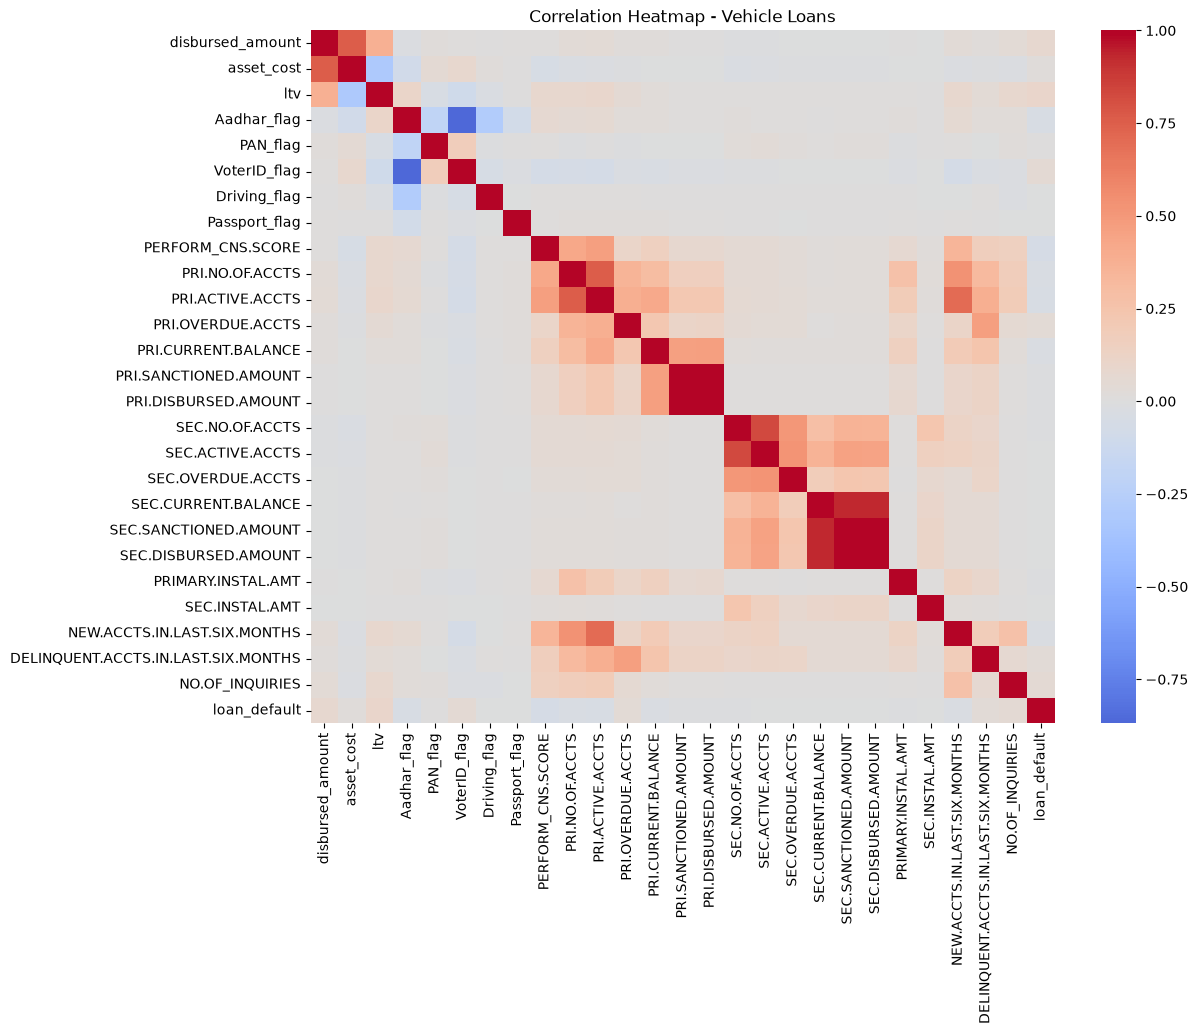

In [120]:
plt.figure(figsize=(12, 9))
sns.heatmap(lt_df.drop(columns=id_cols).corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Vehicle Loans')
plt.show()

In [121]:
# Are there outliers? how would you handle them?

money_cols = ['disbursed_amount', 'asset_cost', 'ltv', 'PERFORM_CNS.SCORE','PRI.CURRENT.BALANCE', 'PRI.SANCTIONED.AMOUNT', 'PRI.DISBURSED.AMOUNT','SEC.CURRENT.BALANCE', 'PRIMARY.INSTAL.AMT', 'SEC.INSTAL.AMT','NO.OF_INQUIRIES']

lt_df[money_cols].describe().round(1)

,disbursed_amount,asset_cost,ltv,PERFORM_CNS.SCORE,PRI.CURRENT.BALANCE,PRI.SANCTIONED.AMOUNT,PRI.DISBURSED.AMOUNT,SEC.CURRENT.BALANCE,PRIMARY.INSTAL.AMT,SEC.INSTAL.AMT,NO.OF_INQUIRIES
count,233154.0,233154.0,233154.0,233154.0,233154.0,2.331540e+05,2.331540e+05,233154.0,233154.0,233154.0,233154.0
mean,54357.0,75865.1,74.7,289.5,165900.1,2.185039e+05,2.180659e+05,5427.8,13105.5,323.3,0.2
std,12971.3,18944.8,11.5,338.4,942273.6,2.374794e+06,2.377744e+06,170237.0,151367.9,15553.7,0.7
min,13320.0,37000.0,10.0,0.0,-6678296.0,0.000000e+00,0.000000e+00,-574647.0,0.0,0.0,0.0
25%,47145.0,65717.0,68.9,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0
50%,53803.0,70946.0,76.8,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0
75%,60413.0,79201.8,83.7,678.0,35006.5,6.250000e+04,6.080000e+04,0.0,1999.0,0.0,0.0
max,990572.0,1628992.0,95.0,890.0,96524920.0,1.000000e+09,1.000000e+09,36032852.0,25642806.0,4170901.0,36.0


In [122]:
for col in money_cols:
    Q1 = lt_df[col].quantile(0.25)
    Q3 = lt_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = lt_df[(lt_df[col] < Q1 - 1.5 * IQR) | (lt_df[col] > Q3 + 1.5 * IQR)]
    print(f'{col} {len(outliers)} outliers')

disbursed_amount 9868 outliers
asset_cost 24388 outliers
ltv 6170 outliers
PERFORM_CNS.SCORE 0 outliers
PRI.CURRENT.BALANCE 41044 outliers
PRI.SANCTIONED.AMOUNT 39587 outliers
PRI.DISBURSED.AMOUNT 39712 outliers
SEC.CURRENT.BALANCE 3364 outliers
PRIMARY.INSTAL.AMT 38868 outliers
SEC.INSTAL.AMT 2217 outliers
NO.OF_INQUIRIES 31193 outliers


In [123]:
# So yes, a lot of outliers

# My plan:
# I will not delete them. a customer with a large existing loan book is a real customer, and rows would be lost.
# I can use Log transform, the money columns to compress the tail while keeping every row.